In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
# create test data for classification using logistic regression
from sklearn.datasets import make_classification
X, Y = make_classification(n_samples=1000, n_features=20, n_informative=2, n_redundant=10, random_state=42)


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,         # 20% for testing, 80% for training
    random_state=42        # For reproducibility
)

In [10]:
# define the model
model = LogisticRegression(penalty='l2')

# train the model
model.fit(X_train, Y_train)

# create the predictions
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

# build the confusion matrices
confusion_matrix_train = confusion_matrix(Y_train, Y_train_pred)
confusion_matrix_test = confusion_matrix(Y_test, Y_test_pred)

# calculate accuracies
train_accuracy = accuracy_score(Y_train, Y_train_pred)
test_accuracy = accuracy_score(Y_test, Y_test_pred)

# display the results
print('Training Confusion Matrix')
print(confusion_matrix_train)
print()
print(f'Training accuracy = {train_accuracy}')
print()
print('Testing Confusion Matrix')
print(confusion_matrix_test)
print()
print(f'Testing accuracy = {test_accuracy}')

Training Confusion Matrix
[[338  56]
 [ 57 349]]

Training accuracy = 0.85875

Testing Confusion Matrix
[[99 12]
 [13 76]]

Testing accuracy = 0.875


Best test accuracy was achieved with C = 0.0035272361809045227, giving an accuracy of 0.88.
Without regularisation, we achieved an accuracy of 0.875.



/Users/kaashif/Development/PyCharmProjects/Imperial_course/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kaashif/Development/PyCharmProjects/Imperial_course/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

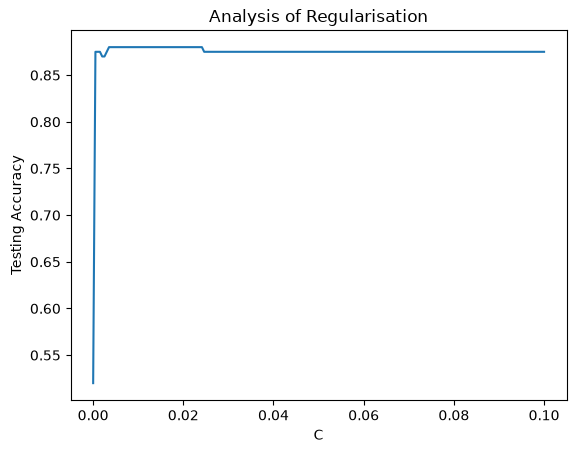

In [13]:
C_space = np.linspace(10e-6, 10e-2, 200)

accuracies = []

for C in C_space:
    model = LogisticRegression(penalty='l2', C=C)
    model.fit(X_train, Y_train)
    Y_test_pred = model.predict(X_test)
    accuracies.append(accuracy_score(Y_test, Y_test_pred))

plt.plot(C_space, accuracies)
plt.xlabel('C')
plt.ylabel('Testing Accuracy')
plt.title('Analysis of Regularisation')

best_model = np.argmax(accuracies)
best_accuracy = accuracies[best_model]
best_C = C_space[best_model]

print(f'Best test accuracy was achieved with C = {best_C}, giving an accuracy of {best_accuracy}.')
print(f'Without regularisation, we achieved an accuracy of {test_accuracy}.')
print()